# INF2005 steganography demonstration

This notebook sends messages through PNG and WAV carriers. A sender embeds and signs
an encrypted record. Protocol version 2 places `record nonce` and user content inside
the AES-256-GCM record; its RSA-OAEP bootstrap carries the separate `aead nonce`,
session key, and packet geometry. Only the receiver private key can recover the
packet location.

## Setup

`samples/Banana.png` is the cover image. Generated files go to a temporary
directory and are removed at the end.

In [1]:
import os
import sys
import tempfile
import wave
from datetime import datetime, timezone
from pathlib import Path

from cryptography.hazmat.primitives import hashes
from cryptography.hazmat.primitives.asymmetric import padding
from cryptography.hazmat.primitives.asymmetric import rsa
from cryptography.hazmat.primitives.ciphers.aead import AESGCM

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "stego" / "__init__.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
from IPython.display import Audio
from IPython.display import display
from PIL import Image, ImageDraw, ImageFont

from stego import *

_demo_temp = tempfile.TemporaryDirectory(prefix="inf2005-demo-")
DEMO_DIR = Path(_demo_temp.name)
sample_png_path = REPO_ROOT / "samples" / "Banana.png"


def preview_image(path):
    with Image.open(path) as image:
        preview = image.copy()
    preview.thumbnail((320, 392))
    return preview


def show_panels(panels, scale=1, gap=16, background="white", direction="horizontal"):
    font = ImageFont.load_default()
    prepared = []
    for image, label in panels:
        image = image.convert("RGB")
        image = image.resize((image.width * scale, image.height * scale), Image.Resampling.NEAREST)
        prepared.append((image, str(label)))
    label_height = max(font.getbbox(label)[3] - font.getbbox(label)[1] for _, label in prepared)
    panel_top = label_height + 8
    if direction == "horizontal":
        canvas_width = sum(image.width for image, _ in prepared) + gap * (len(prepared) - 1)
        canvas_height = panel_top + max(image.height for image, _ in prepared) + 2
    elif direction == "vertical":
        canvas_width = max(image.width for image, _ in prepared)
        canvas_height = sum(panel_top + image.height + 2 for image, _ in prepared) + gap * (len(prepared) - 1)
    else:
        raise ValueError("direction must be horizontal or vertical")
    canvas = Image.new("RGB", (canvas_width, canvas_height), background)
    draw = ImageDraw.Draw(canvas)
    if direction == "horizontal":
        positions = ((sum(image.width + gap for image, _ in prepared[:index]), panel_top) for index in range(len(prepared)))
    else:
        positions = ((0, panel_top + sum(panel_top + image.height + 2 + gap for image, _ in prepared[:index])) for index in range(len(prepared)))
    for (image, label), (x, y) in zip(prepared, positions):
        draw.text((x, y - panel_top + 2), label, fill="black", font=font)
        panel_y = y
        canvas.paste(image, (x, panel_y))
        draw.rectangle((x, panel_y, x + image.width - 1, panel_y + image.height - 1), outline="black", width=1)
    return canvas

def print_hexdump(data, start=0, end=None):
    end = len(data) if end is None else min(end, len(data))
    for offset in range(start, end, 16):
        chunk = data[offset:min(offset + 16, end)]
        print(f"{offset:04x}: {chunk.hex(' ')}")

print(f"Temporary demonstration files: {DEMO_DIR}")
print(f"Sample cover: {sample_png_path}")

Temporary demonstration files: /tmp/inf2005-demo-bgmqky58
Sample cover: /home/yangxuan/Projects/School-Repos/external/INF2005-ACW1/samples/Banana.png


## Sender

The sender loads a cover, chooses embedding settings, signs a message, and writes
a stego file.

### Load the cover image

The media adapter accepts this RGB PNG. The display is smaller, but encoding uses
the full array.

Input path: /home/yangxuan/Projects/School-Repos/external/INF2005-ACW1/samples/Banana.png
Array shape: (1568, 1280, 3)
Array dtype: uint8


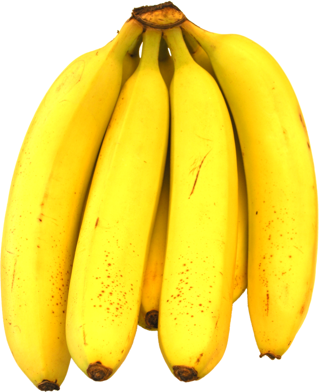

In [2]:
cover_array = load_png_from_path(sample_png_path)
cover_carrier = rgb_array_to_carrier(cover_array)
cover_image = Image.fromarray(cover_array, mode="RGB")
cover_display = cover_image.copy()
cover_display.thumbnail((320, 392))
print("Input path:", sample_png_path)
print("Array shape:", cover_array.shape)
print("Array dtype:", cover_array.dtype)
display(cover_display)

### Choose the message and embedding settings

A carrier unit is one byte used for embedding. The LSB count (`k`) is the number
of low bits used in each unit. The sender chooses a packet start at or after the
2,048-unit RSA-2048 bootstrap span; the bootstrap records the start and `k` for the
receiver. The image provides 6,021,120 carrier units.

In [3]:
private_key, public_key = generate_rsa_keypair()
receiver_private_key, receiver_public_key = generate_rsa_keypair()
public_key_path = DEMO_DIR / "banana-public-key.pem"
stego_png_path = DEMO_DIR / "banana-stego.png"
save_rsa_public_key_pem(public_key, public_key_path)
start_unit = 2997120
lsb_count = 3
image_message = b"INF2005 end-to-end image demonstration"
image_metadata = b"kind=png;flow=sender-receiver"
print(f"Carrier units: {cover_array.shape[1]}*{cover_array.shape[0]}*{cover_array.shape[2]} = {cover_carrier.size}")
print(f"Capacity at k={lsb_count}: {cover_carrier.size * lsb_count} bits ({cover_carrier.size * lsb_count // 8} bytes before packet overhead)")
print("Start unit:", start_unit)
print("LSB count:", lsb_count)
print("Message bytes:", image_message)
print("Metadata:", image_metadata)
print("Public-key fingerprint:", display_rsa_public_key_fingerprint(public_key))

Carrier units: 1280*1568*3 = 6021120
Capacity at k=3: 18063360 bits (2257920 bytes before packet overhead)
Start unit: 2997120
LSB count: 3
Message bytes: b'INF2005 end-to-end image demonstration'
Metadata: b'kind=png;flow=sender-receiver'
Public-key fingerprint: SHA256:9bjPVG0ITjgijD0NPCmxpYTNWk4/IXLenzTmeUPv474


### Embed the message

`encode_png` writes an AES-256-GCM encrypted record and its RSA-PSS signature, then
writes the RSA-OAEP bootstrap. It returns the layout and the sender-side payload.

In [4]:
png_layout, png_payload = encode_png(
    sample_png_path,
    stego_png_path,
    private_key,
    receiver_public_key,
    start_unit=start_unit,
    lsb_count=lsb_count,
    user_payload=image_message,
    metadata=image_metadata,
)

### Inspect the packet

Here is what the encoder produced: where the packet sits and what it contains. A
footprint is the range of carrier units used by the packet. The media hash is a
digest of the carrier with the embedded low bits masked out.

In [5]:
print("Layout.start_unit:", png_layout.start_unit)
print("Layout.lsb_count:", png_layout.lsb_count)
print("Layout.ciphertext_length:", png_layout.ciphertext_length)
print("Layout.footprint:", png_layout.footprint)
print("Layout.pad_bits:", png_layout.pad_bits)
print("Payload.media_id:", png_payload.media_id)
print("Payload.timestamp (integer):", png_payload.timestamp)
print("Payload.timestamp (UTC):", datetime.fromtimestamp(png_payload.timestamp, timezone.utc).isoformat())
print("Payload.nonce (hex):", png_payload.nonce.hex())
print("Payload.media_hash (hex):", png_payload.media_hash.hex())
print("Payload.user_payload:", png_payload.user_payload)
print("Payload.metadata:", png_payload.metadata)
png_payload_bytes = serialize_payload(png_payload)
print("Serialized payload hexdump (first 64 and last 16 bytes):")
print_hexdump(png_payload_bytes, 0, 64)
print(f"... [{len(png_payload_bytes) - 80} bytes skipped] ...")
print_hexdump(png_payload_bytes, len(png_payload_bytes) - 16)


Layout.start_unit: 2997120
Layout.lsb_count: 3
Layout.ciphertext_length: 192
Layout.footprint: 1195
Layout.pad_bits: 1
Payload.media_id: IMG-fea82a462b3c6eaa20fdee1a7598effa
Payload.timestamp (integer): 1789440518
Payload.timestamp (UTC): 2026-09-15T02:48:38+00:00
Payload.nonce (hex): 87964ff8859276fe4eed7407d4a01649
Payload.media_hash (hex): 7f73c2bfdfa1821484b3509fef47b09aa577d850424b4f3f79d3bbcc9d27f80c
Payload.user_payload: b'INF2005 end-to-end image demonstration'
Payload.metadata: b'kind=png;flow=sender-receiver'
Serialized payload hexdump (first 64 and last 16 bytes):
0000: 24 49 4d 47 2d 66 65 61 38 32 61 34 36 32 62 33
0010: 63 36 65 61 61 32 30 66 64 65 65 31 61 37 35 39
0020: 38 65 66 66 61 00 00 00 00 6a a8 b2 06 87 96 4f
0030: f8 85 92 76 fe 4e ed 74 07 d4 a0 16 49 7f 73 c2
... [96 bytes skipped] ...
00a0: 3d 73 65 6e 64 65 72 2d 72 65 63 65 69 76 65 72


### What the signature covers

The signed bytes begin with `INF2005-ACW1\0SIGN\0`. They contain the protocol
version from the sender's constant, the recovered `flags` value, media code, LSB
count, total units, start unit, footprint, `ciphertext_length`, media context, and
the ciphertext. The asymmetry is deliberate: `flags` is signed as recovered from
the bootstrap, while the version is always taken from the protocol constant.
Because the recovered geometry is signed, moving the packet invalidates the
signature even when its encrypted bytes are unchanged.

In [6]:
# The signature covers the ciphertext, protocol geometry, and media context.
png_stego_carrier = rgb_array_to_carrier(load_png_from_path(stego_png_path))
png_packet_bits = read_lsb_bits(png_stego_carrier[png_layout.start_unit:png_layout.start_unit + png_layout.footprint], png_layout.footprint * png_layout.lsb_count, png_layout.lsb_count)
png_packet = bit_sequence_to_bytes(png_packet_bits[:(png_layout.ciphertext_length + RSA_SIGNATURE_SIZE) * 8])
png_ciphertext = png_packet[:png_layout.ciphertext_length]
png_signed_input = encode_signing_input(IMAGE_MEDIA_CODE, encode_png_media_context(cover_array.shape, cover_carrier.size), png_layout, png_ciphertext)
print("Signed-input length:", len(png_signed_input))
print("Encrypted ciphertext length:", len(png_ciphertext))
print("Signed-input hexdump (first 96 bytes):")
print_hexdump(png_signed_input, 0, 96)


Signed-input length: 253
Encrypted ciphertext length: 192
Signed-input hexdump (first 96 bytes):
0000: 49 4e 46 32 30 30 35 2d 41 43 57 31 00 53 49 47
0010: 4e 00 02 01 03 00 00 00 00 00 5b e0 00 00 00 00
0020: 00 00 2d bb 80 00 00 00 00 00 00 04 ab 00 00 00
0030: 00 00 00 00 c0 00 00 05 00 00 00 06 20 e2 1f 44
0040: 20 ad cc 0c a8 a6 ba d1 9c be 5d bd b8 ba b7 b9
0050: d5 bf 0c 36 49 e7 20 f6 e2 f6 86 fd e9 28 a6 e7


### Inspect the written image

At normal scale, the cover and stego image look the same. The table compares real
carrier units before and after embedding. With `k=3`, only the low three bits may
differ. The current packet uses 389 pixels out of 2,007,040. The red strip and
stacked panels use one window centred on the first packet pixel. The strip contains
the full packet with a small margin. The packet caption describes the full packet;
the window caption describes the zoom. The mask is black at both margins, then a
white line runs across the centre row for nearly the full strip width.

Stego path: /tmp/inf2005-demo-bgmqky58/banana-stego.png
Stego file bytes: 1675271
Differing pixel values: 2125
Cover values across packet footprint: min= 0 max= 255
First 8 carrier units at packet location:
index | cover decimal | cover binary | stego decimal | stego binary
    0 |            130 | 10000010 |            135 | 10000111
    1 |             85 | 01010101 |             80 | 01010000
    2 |              0 | 00000000 |              4 | 00000100
    3 |            118 | 01110110 |            113 | 01110001
    4 |             74 | 01001010 |             79 | 01001111
    5 |              0 | 00000000 |              5 | 00000101
    6 |            115 | 01110011 |            112 | 01110000
    7 |             74 | 01001010 |             76 | 01001100
Packet region: 398 pixels of 2,007,040 (0.02% of the image)
Packet span: row 780, columns 640 to 1037
Zoom window: 422×27 pixels, rows 767 to 793, columns 628 to 1049; full packet with margins


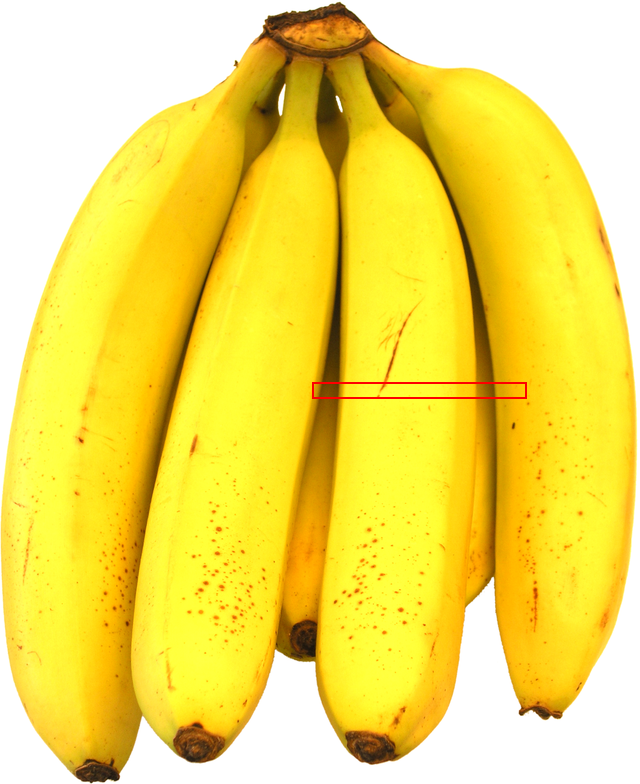

In [7]:
stego_array = load_png_from_path(stego_png_path)
stego_image = Image.fromarray(stego_array, mode="RGB")
stego_carrier = rgb_array_to_carrier(stego_array)
packet_cover_units = cover_carrier[png_layout.start_unit:png_layout.start_unit + png_layout.footprint]
packet_stego_units = stego_carrier[png_layout.start_unit:png_layout.start_unit + png_layout.footprint]
print("Stego path:", stego_png_path)
print("Stego file bytes:", stego_png_path.stat().st_size)
print("Differing pixel values:", int(np.count_nonzero(stego_array != cover_array)))
print("Cover values across packet footprint: min=", int(packet_cover_units.min()), "max=", int(packet_cover_units.max()))
print("First 8 carrier units at packet location:")
print("index | cover decimal | cover binary | stego decimal | stego binary")
for offset, (cover_value, stego_value) in enumerate(zip(packet_cover_units[:8], packet_stego_units[:8])):
    print(f"{offset:5d} | {int(cover_value):14d} | {int(cover_value):08b} | {int(stego_value):14d} | {int(stego_value):08b}")

packet_start_pixel = png_layout.start_unit // cover_array.shape[2]
packet_pixel_count = png_layout.footprint // cover_array.shape[2]
packet_end_pixel = packet_start_pixel + packet_pixel_count - 1
packet_start_y, packet_start_x = divmod(packet_start_pixel, cover_array.shape[1])
packet_end_y, packet_end_x = divmod(packet_end_pixel, cover_array.shape[1])
total_pixel_count = cover_array.shape[0] * cover_array.shape[1]
horizontal_margin = 12
vertical_margin = 13
window_box = (
    packet_start_x - horizontal_margin,
    packet_start_y - vertical_margin,
    packet_end_x + horizontal_margin + 1,
    packet_end_y + vertical_margin + 1,
)
window_width = window_box[2] - window_box[0]
window_height = window_box[3] - window_box[1]
whole_image = cover_image.copy()
whole_display = whole_image.resize((640, 784), Image.Resampling.LANCZOS)
display_scale_x = whole_display.width / whole_image.width
display_scale_y = whole_display.height / whole_image.height
display_window_box = (
    round(window_box[0] * display_scale_x) - 2,
    round(window_box[1] * display_scale_y) - 2,
    round(window_box[2] * display_scale_x) + 1,
    round(window_box[3] * display_scale_y) + 1,
)
ImageDraw.Draw(whole_display).rectangle(display_window_box, outline="red", width=2)
print(f"Packet region: {packet_pixel_count:,} pixels of {total_pixel_count:,} ({packet_pixel_count / total_pixel_count:.2%} of the image)")
print(f"Packet span: row {packet_start_y}, columns {packet_start_x} to {packet_end_x}")
print(f"Zoom window: {window_width}×{window_height} pixels, rows {window_box[1]} to {window_box[3] - 1}, columns {window_box[0]} to {window_box[2] - 1}; full packet with margins")
display(whole_display)

### Inspect the packet window

The zoomed panels show the cover, stego image, and changed carrier units.

Full packet strip, stacked at 2x: cover, stego, changed units:


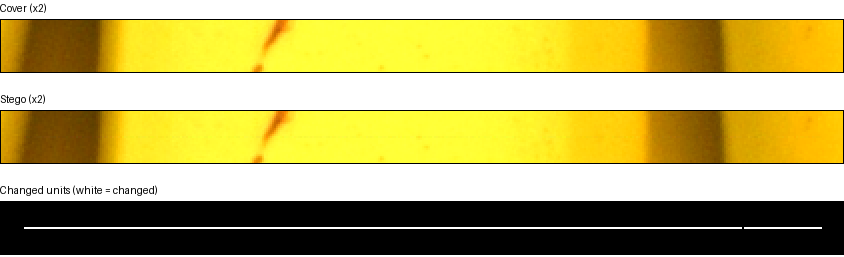

In [8]:
print("Full packet strip, stacked at 2x: cover, stego, changed units:")
cover_crop = cover_image.crop(window_box)
stego_crop = stego_image.crop(window_box)
changed_carrier = stego_carrier != cover_carrier
changed_pixel_mask = np.any(changed_carrier.reshape(cover_array.shape), axis=2)
changed_mask_image = Image.fromarray(np.where(changed_pixel_mask, 255, 0).astype(np.uint8), mode="L")
changed_crop = changed_mask_image.crop(window_box)
display(show_panels([(cover_crop, "Cover (x2)"), (stego_crop, "Stego (x2)"), (changed_crop, "Changed units (white = changed)")], scale=2, direction="vertical"))

### End the sender phase

The sender keeps the signing private key private. The receiver needs the sender
public key and receiver private key; the packet geometry is carried inside the
receiver's RSA-OAEP bootstrap rather than passed as plaintext out of band.

In [9]:
# The receiver needs only the sender public key and receiver private key.
receiver_sender_public_key = public_key
receiver_bootstrap_span = bootstrap_span(receiver_private_key)
del private_key, public_key


## Receiver

The receiver opens the RSA-OAEP bootstrap with the receiver private key, recovers
the packet geometry and session material, then verifies the sender's RSA-PSS
signature and AES-GCM record.

### Files and keys available to the receiver

The receiver has the stego image path, the sender public-key PEM path, and the
receiver private key. No start unit, LSB count, or record length is transported
separately; those values are recovered from the bootstrap.

In [10]:
print("Stego file path:", stego_png_path)
print("Sender public-key PEM path:", public_key_path)
receiver_private_key_path = DEMO_DIR / "banana-receiver-private-key.pem"
receiver_private_key_password = b"receiver-demo-password"
save_rsa_private_key_pem(receiver_private_key, receiver_private_key_path, password=receiver_private_key_password)
receiver_private_key = load_rsa_private_key_pem(receiver_private_key_path, password=receiver_private_key_password)
print("Receiver private key loaded from password-protected PEM:", receiver_private_key_path)


Stego file path: /tmp/inf2005-demo-bgmqky58/banana-stego.png
Sender public-key PEM path: /tmp/inf2005-demo-bgmqky58/banana-public-key.pem
Receiver private key loaded from password-protected PEM: /tmp/inf2005-demo-bgmqky58/banana-receiver-private-key.pem


### How the start location is secured

The sender chooses the packet start and LSB count, subject to the start being at or
after the reserved bootstrap span. The sender writes those values, the ciphertext
length, session key, and `aead_nonce` into the RSA-OAEP bootstrap at fixed unit 0.
The receiver reads that one bootstrap with the receiver private key and uses the
recovered geometry to find the same packet.

**Claimed:** without the receiver private key, the packet location cannot be
recovered from protocol structure or locator metadata. The record and geometry
fields are encrypted or authenticated, so unauthorised extraction is refused.

**Not claimed:** the bootstrap is not hidden; its fixed span is observable. Statistical
steganalysis is out of scope. An attacker can overwrite unit 0 and cheaply destroy
extraction; this denial of service does not leave a useful tamper signal.

In [11]:
receiver_geometry = {"bootstrap_span": receiver_bootstrap_span, "location_and_length": "encrypted in the RSA-OAEP bootstrap"}
print("Receiver bootstrap:", receiver_geometry)


Receiver bootstrap: {'bootstrap_span': 2048, 'location_and_length': 'encrypted in the RSA-OAEP bootstrap'}


### Verify the payload

The receiver loads the sender public key and receiver private key, opens the
bootstrap, recovers the geometry, and verifies the stego image. A valid result
returns the media ID, timestamp, and message.

In [12]:
sender_public_key = load_rsa_public_key_pem(public_key_path)
png_result = verify_png(stego_png_path, sender_public_key, receiver_private_key)
print("PNG verdict:", png_result.verdict)
print("Key fingerprint:", png_result.key_fingerprint)
print("Media ID:", png_result.payload.media_id)
print("Timestamp:", png_result.payload.timestamp)
print("Recovered message:", png_result.payload.user_payload.decode("utf-8"))


PNG verdict: Authentic
Key fingerprint: SHA256:9bjPVG0ITjgijD0NPCmxpYTNWk4/IXLenzTmeUPv474
Media ID: IMG-fea82a462b3c6eaa20fdee1a7598effa
Timestamp: 1789440518
Recovered message: INF2005 end-to-end image demonstration


## Failure cases

The matrix below separates sender-authentication failure, receiver-bootstrap failure,
location bounds, decryption failure, and carrier tampering. The untouched cover is
treated as having no readable payload.

### Altered image

Change one carrier unit outside the packet. The signature still verifies, but the
masked media hash reports tampering.

In [13]:
altered_png_path = DEMO_DIR / "banana-altered.png"
altered_image = load_png_from_path(stego_png_path)
altered_carrier = rgb_array_to_carrier(altered_image)
altered_carrier[-1] ^= np.uint8(1)
save_rgb_png_to_path(carrier_to_rgb_array(altered_carrier, altered_image.shape), altered_png_path)
print("Altered PNG verdict:", verify_png(altered_png_path, sender_public_key, receiver_private_key).verdict)

Altered PNG verdict: Tampered


### Wrong sender public key

A signature made by the sender cannot be verified with an unrelated sender public
key, so this case is `Signature Invalid`.

In [14]:
wrong_sender_private_key, wrong_sender_public_key = generate_rsa_keypair()
print("Wrong sender-key PNG verdict:", verify_png(stego_png_path, wrong_sender_public_key, receiver_private_key).verdict)
del wrong_sender_private_key, wrong_sender_public_key


Wrong sender-key PNG verdict: Signature Invalid


### Wrong receiver private key

A file addressed to another receiver and a file with no payload are indistinguishable.
Both fail at RSA-OAEP opening and produce `Payload Missing`.

In [15]:
wrong_receiver_private_key, wrong_receiver_public_key = generate_rsa_keypair()
print("Wrong receiver-key PNG verdict:", verify_png(stego_png_path, sender_public_key, wrong_receiver_private_key).verdict)
del wrong_receiver_private_key, wrong_receiver_public_key


Wrong receiver-key PNG verdict: Payload Missing


### Untouched cover

The original cover has no readable RSA-OAEP bootstrap, so verification returns
`Payload Missing`.

In [16]:
print("Untouched cover verdict:", verify_png(sample_png_path, sender_public_key, receiver_private_key).verdict)
del altered_image, altered_carrier

Untouched cover verdict: Payload Missing


### Does the raw payload fit?

The raw RGB data is 1280 × 1568 × 3 = 6,021,120 bytes, exactly one byte per
carrier unit. At `k=8`, the carrier can hold one byte per unit, but the packet also
needs the 2,048-unit RSA-OAEP bootstrap, its encrypted record and GCM tag, its
RSA-PSS signature, and alignment. The first refusal below is therefore a
payload-too-large refusal, not a too-small-carrier refusal. The adjacent case shows
the separate too-small-carrier refusal: a zero user capacity is valid only when the
complete protocol object fits exactly. The PNG file is only 1,673,875 bytes because
PNG compresses; using that file would answer a different capacity question.

In [17]:
capacity_cover_array = load_png_from_path(sample_png_path)
capacity_carrier = rgb_array_to_carrier(capacity_cover_array)
capacity_payload = capacity_cover_array.tobytes()
capacity_metadata = b"capacity test"
capacity_at_k8 = capacity_carrier.size * 8 // 8
capacity_private_key, capacity_receiver_public_key = generate_rsa_keypair()
try:
    encode_png(
        sample_png_path,
        DEMO_DIR / "capacity-k8.png",
        capacity_private_key,
        capacity_receiver_public_key,
        start_unit=bootstrap_span(capacity_receiver_public_key),
        lsb_count=8,
        user_payload=capacity_payload,
        metadata=capacity_metadata,
    )
    capacity_result = "Unexpected result: the capacity case was accepted"
except ValueError as error:
    capacity_result = f"Payload-too-large refusal: {error}"
capacity_span = bootstrap_span(capacity_receiver_public_key)
# Fixed-width overhead for the generated 36-byte media id: 73 + 36 = 109 bytes.
capacity_minimum_units = minimum_carrier_units(capacity_span, 8, 109)
capacity_small_carrier = np.arange(capacity_minimum_units - 1, dtype=np.uint8)
capacity_small_context = encode_png_media_context((1, 1, 3))
capacity_small_refusals = []
for capacity_small_payload in (b"", b"x"):
    try:
        encode_carrier(
            capacity_small_carrier,
            IMAGE_MEDIA_CODE,
            capacity_small_context,
            capacity_private_key,
            capacity_receiver_public_key,
            capacity_span,
            8,
            capacity_small_payload,
            b"",
        )
        capacity_small_refusals.append("Unexpected result: too-small carrier was accepted")
    except ValueError as error:
        capacity_small_refusals.append(str(error))
print(f"Raw RGB payload: {len(capacity_payload):,} bytes")
print(f"Carrier capacity at k=8: {capacity_carrier.size:,} carrier units × 8 bits ÷ 8 = {capacity_at_k8:,} bytes")
print(capacity_result)
print("Too-small-carrier refusal (empty payload):", capacity_small_refusals[0])
print("Too-small-carrier refusal (one-byte payload):", capacity_small_refusals[1])
del capacity_cover_array, capacity_carrier, capacity_payload, capacity_metadata, capacity_at_k8
del capacity_private_key, capacity_receiver_public_key


Raw RGB payload: 6,021,120 bytes
Carrier capacity at k=8: 6,021,120 carrier units × 8 bits ÷ 8 = 6,021,120 bytes
Payload-too-large refusal: user payload exceeds capacity: user_payload_length=6021120, max_user_payload_length=6018678, total_units=6021120, start_unit=2048, lsb_count=8
Too-small-carrier refusal (empty payload): carrier is too small for the protocol: total_units=2428, start_unit=2048, lsb_count=8, minimum_units=2429
Too-small-carrier refusal (one-byte payload): carrier is too small for the protocol: total_units=2428, start_unit=2048, lsb_count=8, minimum_units=2429


### Verdict matrix

This table reaches all seven current verdicts through real verification calls. The
six assignment failure categories are joined by `Cannot Decrypt`, an additional
protocol verdict used when the signature verifies but the AES-GCM body check fails;
calling that `Tampered` or `Cannot Verify` would hide which security check failed.

In [18]:
def bootstrap_fields_from_image(carrier_units):
    span = bootstrap_span(receiver_private_key)
    envelope = bit_sequence_to_bytes(read_lsb_bits(carrier_units[:span], span, BOOTSTRAP_LSB_COUNT))
    return parse_bootstrap(open_with_private_key(envelope, receiver_private_key))


def replace_image_bootstrap(carrier_units, fields):
    envelope = seal_to_public_key(serialize_bootstrap(fields), receiver_public_key)
    result = carrier_units.copy()
    result[:bootstrap_span(receiver_public_key)] = write_lsb_bits(
        result[:bootstrap_span(receiver_public_key)],
        bytes_to_bit_sequence(envelope),
        BOOTSTRAP_LSB_COUNT,
    )
    return result


def verify_image_carrier(carrier_units, sender_key=sender_public_key, receiver_key=receiver_private_key):
    return decode_carrier(
        carrier_units,
        IMAGE_MEDIA_CODE,
        encode_png_media_context(cover_array.shape, carrier_units.size),
        sender_key,
        receiver_key,
    ).verdict

matrix_fields = bootstrap_fields_from_image(stego_carrier)
packet_fields = matrix_fields
packet_bits = read_lsb_bits(
    stego_carrier[png_layout.start_unit:png_layout.start_unit + png_layout.footprint],
    png_layout.footprint * png_layout.lsb_count,
    png_layout.lsb_count,
)
packet = bit_sequence_to_bytes(packet_bits[:(png_layout.ciphertext_length + RSA_SIGNATURE_SIZE) * 8])
ciphertext = packet[:png_layout.ciphertext_length]
signature = packet[png_layout.ciphertext_length:]
wrong_start_fields = BootstrapFields(packet_fields.version, packet_fields.lsb_count, stego_carrier.size, packet_fields.ciphertext_length, packet_fields.session_key, packet_fields.aead_nonce)
wrong_start_carrier = replace_image_bootstrap(stego_carrier, wrong_start_fields)
wrong_session = bytes((packet_fields.session_key[0] ^ 1,)) + packet_fields.session_key[1:]
wrong_session_fields = BootstrapFields(packet_fields.version, packet_fields.lsb_count, packet_fields.start_unit, packet_fields.ciphertext_length, wrong_session, packet_fields.aead_nonce)
cannot_decrypt_carrier = replace_image_bootstrap(stego_carrier, wrong_session_fields)
malformed_carrier = stego_carrier.copy()
malformed_envelope = seal_to_public_key(b"malformed bootstrap", receiver_public_key)
malformed_carrier[:bootstrap_span(receiver_public_key)] = write_lsb_bits(
    malformed_carrier[:bootstrap_span(receiver_public_key)],
    bytes_to_bit_sequence(malformed_envelope),
    BOOTSTRAP_LSB_COUNT,
)
tampered_carrier = stego_carrier.copy()
tampered_carrier[-1] ^= np.uint8(1)
wrong_sender_private, wrong_sender = generate_rsa_keypair()
verdict_rows = [
    ("Authentic", verify_image_carrier(stego_carrier)),
    ("Tampered", verify_image_carrier(tampered_carrier)),
    ("Signature Invalid", verify_image_carrier(stego_carrier, wrong_sender)),
    ("Payload Missing", verify_image_carrier(cover_carrier)),
    ("Wrong Start Location", verify_image_carrier(wrong_start_carrier)),
    ("Cannot Decrypt", verify_image_carrier(cannot_decrypt_carrier)),
    ("Cannot Verify", verify_image_carrier(malformed_carrier)),
]
for name, observed in verdict_rows:
    print(f"{name:20} {observed}")
del wrong_sender_private, wrong_sender


Authentic            Authentic
Tampered             Tampered
Signature Invalid    Signature Invalid
Payload Missing      Payload Missing
Wrong Start Location Wrong Start Location
Cannot Decrypt       Cannot Decrypt
Cannot Verify        Cannot Verify


## WAV example

The same sender/receiver flow works for a mono 8-bit PCM sine tone. The final
alteration shows tamper detection.

In [19]:
wav_cover_path = DEMO_DIR / "tone-cover.wav"
wav_stego_path = DEMO_DIR / "tone-stego.wav"
wav_public_key_path = DEMO_DIR / "tone-public-key.pem"
wav_altered_path = DEMO_DIR / "tone-altered.wav"
wav_samples = (128 + 90 * np.sin(2 * np.pi * 440 * np.arange(32000) / 8000)).astype(np.uint8).tobytes()
with wave.open(str(wav_cover_path), "wb") as wav_file:
    wav_file.setnchannels(1)
    wav_file.setsampwidth(1)
    wav_file.setframerate(8000)
    wav_file.writeframes(wav_samples)

wav_private_key, wav_public_key = generate_rsa_keypair()
wav_receiver_private_key, wav_receiver_public_key = generate_rsa_keypair()
wav_start_unit = bootstrap_span(wav_receiver_public_key)
wav_lsb_count = 5
wav_layout, _ = encode_wav(
    wav_cover_path,
    wav_stego_path,
    wav_private_key,
    wav_receiver_public_key,
    start_unit=wav_start_unit,
    lsb_count=wav_lsb_count,
    user_payload=b"INF2005 end-to-end audio demonstration",
    metadata=b"kind=wav;flow=sender-receiver",
)
save_rsa_public_key_pem(wav_public_key, wav_public_key_path)

# Keep the WAV receiver step independent of the sender's key too.
del wav_private_key, wav_public_key, wav_layout, wav_samples
del wav_start_unit, wav_lsb_count
wav_sender_public_key = load_rsa_public_key_pem(wav_public_key_path)
wav_result = verify_wav(wav_stego_path, wav_sender_public_key, wav_receiver_private_key)
print("WAV verdict:", wav_result.verdict)
print("Key fingerprint:", wav_result.key_fingerprint)
print("WAV recovered message:", wav_result.payload.user_payload.decode("utf-8"))

wav_data = load_pcm_wav_from_path(wav_stego_path)
wav_carrier = wav_frame_bytes_to_carrier(wav_data.frame_bytes, wav_data.sample_width)
wav_carrier[-1] ^= np.uint8(1)
save_pcm_wav_to_path(wav_data_with_carrier(wav_data, wav_carrier), wav_altered_path)
print("Altered WAV verdict:", verify_wav(wav_altered_path, wav_sender_public_key, wav_receiver_private_key).verdict)
del wav_data, wav_carrier

WAV verdict: Authentic
Key fingerprint: SHA256:rOBFyq8RxWtzvGUxq4Cn7OnXC5HER+6sPKJbYNgute0
WAV recovered message: INF2005 end-to-end audio demonstration


Altered WAV verdict: Tampered


## Analysis: compare `k=1` and `k=8`

A larger `k` uses more low bits per carrier unit and needs fewer units for the
packet. Compare the footprint and visual effect.

The preserved-bit count is identical here for a reason, not because the results
were copied. Bits overwritten equal `k × footprint`, which is the packet bits plus
zero pad bits: `1 × 3384 = 3384` at k=1, and `8 × 423 = 3384` at k=8. The packet
has the same bit count either way, so preserved bits depend on packet bit count,
not on the LSB count. A nonzero pad would make the two figures differ slightly.

The table's `changed_values` column shows the trade: k=8 disturbs fewer carrier
values and changes each one more deeply. The same number of packet bits is replaced,
but those bits are spread across fewer carrier units.


{'k': 1, 'capacity_bits': 6021120, 'packet_bits': 3384, 'footprint': 3384, 'changed_values': 2702, 'preserved_bits': 48163528, 'bootstrap_bits_written': 2048, 'bootstrap_preserved_bits': 14336, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
{'k': 8, 'capacity_bits': 48168960, 'packet_bits': 3384, 'footprint': 423, 'changed_values': 1472, 'preserved_bits': 48163528, 'bootstrap_bits_written': 2048, 'bootstrap_preserved_bits': 14336, 'preserved_ratio': '99.99%', 'verdict': 'Authentic'}
Cover, k=1, and k=8, labelled and downscaled for display:


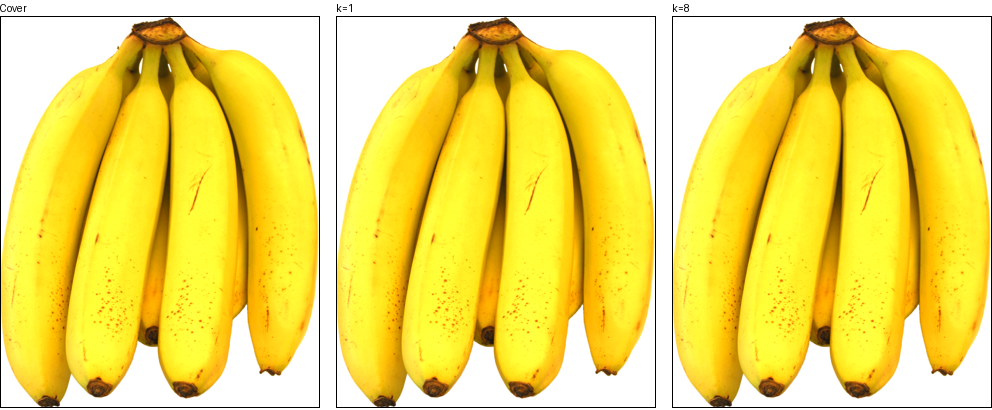

In [20]:
analysis_private_key, analysis_public_key = generate_rsa_keypair()
analysis_receiver_private_key, analysis_receiver_public_key = generate_rsa_keypair()
analysis_rows = []
analysis_previews = []
analysis_cover_array = load_png_from_path(sample_png_path)
analysis_cover_image = Image.fromarray(analysis_cover_array, mode="RGB")
for analysis_k in (1, 8):
    analysis_output = DEMO_DIR / f"banana-analysis-k{analysis_k}.png"
    analysis_layout, _ = encode_png(
        sample_png_path,
        analysis_output,
        analysis_private_key,
        analysis_receiver_public_key,
        start_unit=bootstrap_span(analysis_receiver_public_key),
        lsb_count=analysis_k,
        user_payload=b"same analysis payload",
        metadata=b"analysis=k comparison",
    )
    analysis_result = verify_png(analysis_output, analysis_public_key, analysis_receiver_private_key)
    analysis_image = np.asarray(Image.open(analysis_output), dtype=np.uint8)
    changed_values = int(np.count_nonzero(analysis_image != analysis_cover_array))
    preserved = preserved_bit_count(analysis_layout.total_units, analysis_layout.footprint, analysis_layout.lsb_count, analysis_layout.bootstrap_span)
    packet_bits = (analysis_layout.ciphertext_length + RSA_SIGNATURE_SIZE) * 8
    analysis_rows.append({
        "k": analysis_k,
        "capacity_bits": analysis_layout.total_units * analysis_k,
        "packet_bits": packet_bits,
        "footprint": analysis_layout.footprint,
        "changed_values": changed_values,
        "preserved_bits": preserved,
        "bootstrap_bits_written": analysis_layout.bootstrap_span,
        "bootstrap_preserved_bits": 7 * analysis_layout.bootstrap_span,
        "preserved_ratio": f"{preserved / (analysis_layout.total_units * 8):.2%}",
        "verdict": analysis_result.verdict,
    })
    analysis_preview = Image.fromarray(analysis_image, mode="RGB")
    analysis_preview.thumbnail((320, 392))
    analysis_previews.append((analysis_preview, f"k={analysis_k}"))
for row in analysis_rows:
    print(row)
analysis_cover_preview = analysis_cover_image.copy()
analysis_cover_preview.thumbnail((320, 392))
print("Cover, k=1, and k=8, labelled and downscaled for display:")
display(show_panels([(analysis_cover_preview, "Cover"), *analysis_previews], scale=1))
del analysis_private_key, analysis_public_key, analysis_receiver_private_key, analysis_receiver_public_key, analysis_cover_array, analysis_cover_image, analysis_rows, analysis_previews, analysis_cover_preview

## Confidentiality from the protocol

Protocol version 2 encrypts and signs the complete payload record inside the library.
This directly satisfies the section 5 requirement for a custom payload that protects
confidentiality and integrity. The caller-side seal from the earlier demonstration
is removed under decision 16; its design remains recorded for comparison, but it is
no longer shown. The typed-payload demonstration keeps the MIME claim and original
filename in the existing metadata string, while the raw file bytes remain the user
payload.


## Typed payloads

The typed-payload demonstration stores the declared MIME type and original filename
as `key=value` entries in the existing metadata string, next to `kind` and `flow`.
The recovered `user_payload` is the raw file bytes. The receiver still sniffs those
bytes and checks the declared MIME type before rendering. Values cannot contain `;` or `=`;
the sender refuses such values because those characters delimit the metadata convention.
A receiver verifies first and interprets second: a failed verification has no payload to interpret.


P1: declared mime=text/plain, sniffed mime=None, agree=True, name=note.txt, body length=43, verdict=Authentic
The typed payload reached the text handler.


P2: declared mime=image/png, sniffed mime=image/png, agree=True, name=generated.png, body length=196, verdict=Authentic


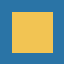

P3: declared mime=audio/wav, sniffed mime=audio/wav, agree=True, name=short-tone.wav, body length=4044, verdict=Authentic


N1: declared mime=image/png, sniffed mime=application/pdf, agree=False, name=not-really.png, body length=19, verdict=Authentic
Payload type mismatch; saved payload: /tmp/inf2005-demo-bgmqky58/handled-not-really.png
Reason: declared MIME 'image/png' does not match sniffed MIME 'application/pdf'


N2: sender declared mime=text/plain, sniffed mime=None, agree=True, sender name=../../etc/passwd, body length=19, verdict=Authentic
N2 rejected: ValueError name must be a safe bare filename


In [21]:
def sniff_mime(body: bytes) -> str | None:
    if body.startswith(b"\x89PNG"):
        return "image/png"
    if body.startswith(b"\xff\xd8\xff"):
        return "image/jpeg"
    if len(body) >= 12 and body[:4] == b"RIFF" and body[8:12] == b"WAVE":
        return "audio/wav"
    if body.startswith(b"%PDF"):
        return "application/pdf"
    return None


SNIFFABLE_MIMES = {"image/png", "image/jpeg", "audio/wav", "application/pdf"}


def mime_agrees(declared: str, body: bytes) -> bool:
    sniffed = sniff_mime(body)
    if sniffed is None:
        return declared not in SNIFFABLE_MIMES
    return sniffed == declared


def handle_payload(mime: str, name: str, body: bytes) -> None:
    safe_name = name.replace("/", "").replace("\\", "").replace("..", "")
    if safe_name in {"", "."}:
        safe_name = "payload.bin"
    output_path = DEMO_DIR / f"handled-{safe_name}"
    if not mime_agrees(mime, body):
        output_path.write_bytes(body)
        print("Payload type mismatch; saved payload:", output_path)
        print(f"Reason: declared MIME {mime!r} does not match sniffed MIME {sniff_mime(body)!r}")
        return
    if mime == "text/plain":
        try:
            print(body.decode("utf-8"))
        except UnicodeDecodeError as error:
            output_path.write_bytes(body)
            print("Invalid text payload; saved payload:", output_path)
            print("Reason:", type(error).__name__, str(error))
        return
    output_path.write_bytes(body)
    if mime in {"image/png", "image/jpeg"}:
        display(preview_image(output_path))
    elif mime in {"audio/wav", "audio/mpeg"}:
        display(Audio(filename=str(output_path)))
    else:
        print("Saved payload:", output_path)


content_receiver_public_key = receiver_public_key
content_sender_private_key, content_sender_public_key = generate_rsa_keypair()

content_image_path = DEMO_DIR / "generated-content.png"
content_image = Image.new("RGB", (64, 64), (42, 116, 166))
content_image_draw = ImageDraw.Draw(content_image)
content_image_draw.rectangle((12, 12, 52, 52), fill=(242, 196, 83))
content_image.save(content_image_path, format="PNG")
content_image_body = content_image_path.read_bytes()

# This 4,000-sample tone is typed payload data, not the WAV cover.
# The WAV cover above contains 32,000 samples.
content_audio_samples = (
    128 + 80 * np.sin(2 * np.pi * 440 * np.arange(4000) / 8000)
).astype(np.uint8).tobytes()
content_audio_path = DEMO_DIR / "generated-content.wav"
with wave.open(str(content_audio_path), "wb") as content_audio_file:
    content_audio_file.setnchannels(1)
    content_audio_file.setsampwidth(1)
    content_audio_file.setframerate(8000)
    content_audio_file.writeframes(content_audio_samples)
# Replace this variable with bytes from a supplied WAV file later.
content_audio_body = content_audio_path.read_bytes()


def run_typed_case(
    label: str,
    declared_mime: str,
    name: str,
    body: bytes,
    stego_name: str,
) -> None:
    if ";" in declared_mime or "=" in declared_mime or ";" in name or "=" in name:
        raise ValueError("metadata values cannot contain ';' or '='")
    content_metadata = (
        f"kind=png;flow=typed-content;mime={declared_mime};name={name}"
    ).encode("utf-8")
    stego_path = DEMO_DIR / stego_name
    layout, _ = encode_png(
        sample_png_path,
        stego_path,
        content_sender_private_key,
        content_receiver_public_key,
        start_unit=bootstrap_span(content_receiver_public_key),
        lsb_count=1,
        user_payload=body,
        metadata=content_metadata,
    )
    result = verify_png(stego_path, content_sender_public_key, receiver_private_key)
    if not result.valid:
        print(f"{label}: verdict={result.verdict}, detail={result.detail}")
        return
    recovered_body = result.payload.user_payload
    try:
        metadata_fields = dict(
            item.split("=", 1)
            for item in result.payload.metadata.decode("utf-8").split(";")
            if "=" in item
        )
        recovered_mime = metadata_fields["mime"]
        recovered_name = metadata_fields["name"]
        if any(part in recovered_name for part in ("/", "\\", "..")):
            raise ValueError("name must be a safe bare filename")
    except (KeyError, UnicodeDecodeError, ValueError) as error:
        sniffed = sniff_mime(recovered_body)
        agrees = mime_agrees(declared_mime, recovered_body)
        print(
            f"{label}: sender declared mime={declared_mime}, sniffed mime={sniffed}, "
            f"agree={agrees}, sender name={name}, body length={len(recovered_body)}, "
            f"verdict={result.verdict}"
        )
        print(f"{label} rejected: {type(error).__name__} {error}")
        return
    sniffed = sniff_mime(recovered_body)
    agrees = mime_agrees(recovered_mime, recovered_body)
    print(
        f"{label}: declared mime={recovered_mime}, sniffed mime={sniffed}, "
        f"agree={agrees}, name={recovered_name}, body length={len(recovered_body)}, "
        f"verdict={result.verdict}"
    )
    handle_payload(recovered_mime, recovered_name, recovered_body)


run_typed_case(
    "P1",
    "text/plain",
    "note.txt",
    b"The typed payload reached the text handler.",
    "typed-text.png",
)
run_typed_case("P2", "image/png", "generated.png", content_image_body, "typed-image.png")
run_typed_case("P3", "audio/wav", "short-tone.wav", content_audio_body, "typed-audio.png")
run_typed_case(
    "N1",
    "image/png",
    "not-really.png",
    b"%PDF-1.7\nnot a PNG\n",
    "typed-negative-pdf.png",
)
run_typed_case(
    "N2",
    "text/plain",
    "../../etc/passwd",
    b"name rejection test",
    "typed-negative-name.png",
)


The metadata string is inside the library-encrypted record. An observer cannot
recover the packet location from protocol structure without the receiver private key.
A signed content type is still a claim by the sender, not a fact about the bytes;
software that renders the payload validates it first. The original filename is also
untrusted metadata: N2 refuses a non-bare name before the writing handler is called.
The 4,000-sample tone is typed payload data, not the 32,000-sample WAV cover.


### Required-case coverage

The notebook demonstrates positive PNG and WAV cases; altered PNG and WAV cases;
wrong sender and receiver keys; pristine-carrier, wrong-location, decryption, and
malformed-bootstrap verdicts; the capacity refusals; the A-to-B receiver-key story;
multiple payload sizes through the typed cases; and selectable `k` values in the
analysis and tests. The team's final message choices and FR13 innovation statement
remain undecided. A live email or folder transfer is still a presentation task, not
simulated by this notebook.

## Clean up

Generated files live in the temporary directory and are removed now.

In [22]:
_demo_temp.cleanup()
print("Temporary demonstration files removed.")

Temporary demonstration files removed.
